# Platform Stabilogram

This file contains:
- extration of stabilogrma from force platform gait-line.csv
- stabilogram is synchronizatinized with begin time extracted from .xml
- stabilogram is centered
- CoP variables are extracted

At the end of the file, there is a comparison plot with radar stabilogram

In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from code_descriptors_postural_control.stabilogram.stato import Stabilogram
from code_descriptors_postural_control.descriptors import compute_all_features

## Here

In [208]:
xml_file = "../data/dataset2/platform/test3.xml"
csv_gait_file = "../data/dataset2/platform/test3_gait.csv"

In [209]:

def get_begin_time(xml_filepath_filenam):
    tree = ET.parse(xml_filepath_filenam)
    root = tree.getroot()

    # définir le namespace
    ns = {"z": "http://www.zebris.de/measurements"}

    # trouver la valeur de begin
    begin = root.find(".//z:clip/z:begin", ns)

    if begin is not None:
        return float(begin.text)
    return 0

print(get_begin_time(xml_file))

-6.75


In [210]:
def get_gait_samples(csv_file):

    df = pd.read_csv(csv_file, skiprows=3)

    times = df["time"].to_numpy()
    xs = df["x"].to_numpy()
    ys = df["y"].to_numpy()

    return times, xs, ys


In [211]:
begin_time = get_begin_time(xml_file)
times, x_pos, y_pos = get_gait_samples(csv_gait_file)


In [212]:
times = times + begin_time
positive_time = np.where((times >= 0))
# positive_time = np.where((times >= 0) & (times <= 10))
times = times[positive_time]
x_pos = x_pos[positive_time]
y_pos = y_pos[positive_time]

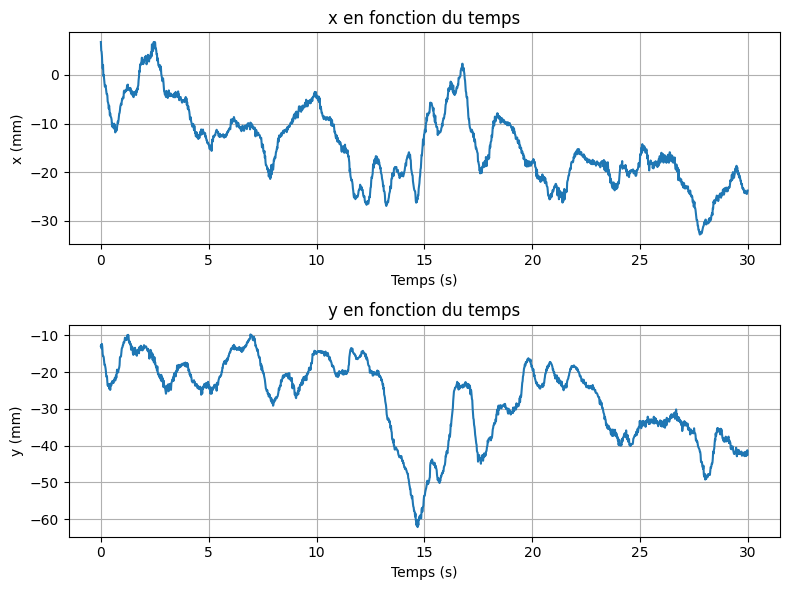

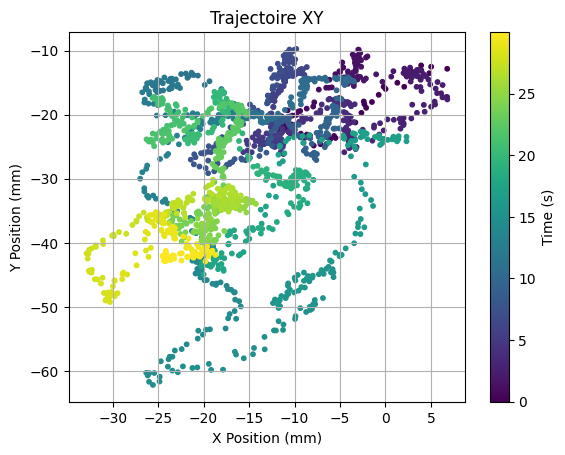

In [213]:

# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Temps (s)")
plt.ylabel("x (mm)")
plt.title("x en fonction du temps")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Temps (s)")
plt.ylabel("y (mm)")
plt.title("y en fonction du temps")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()


## Centered

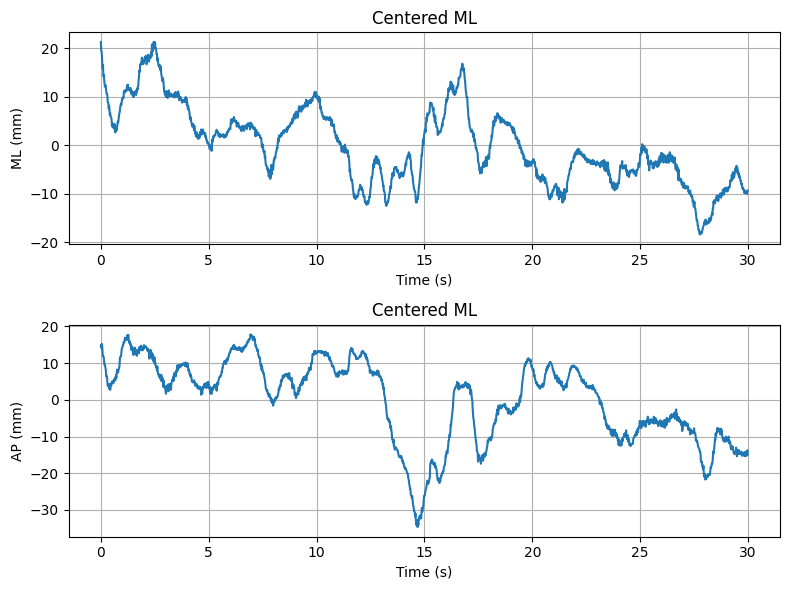

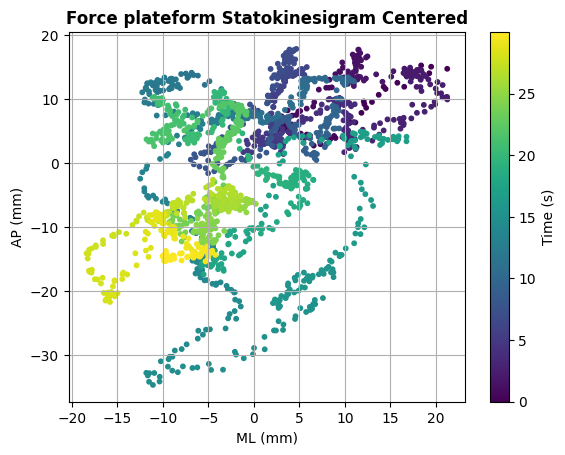

In [214]:
x_pos -= np.mean(x_pos)
y_pos -= np.mean(y_pos)

# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Time (s)")
plt.ylabel("ML (mm)")
plt.title("Centered ML")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Time (s)")
plt.ylabel("AP (mm)")
plt.title("Centered ML")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("ML (mm)")
plt.ylabel("AP (mm)")
plt.title("Force plateform Statokinesigram Centered", fontweight='bold')
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()


## Normalization

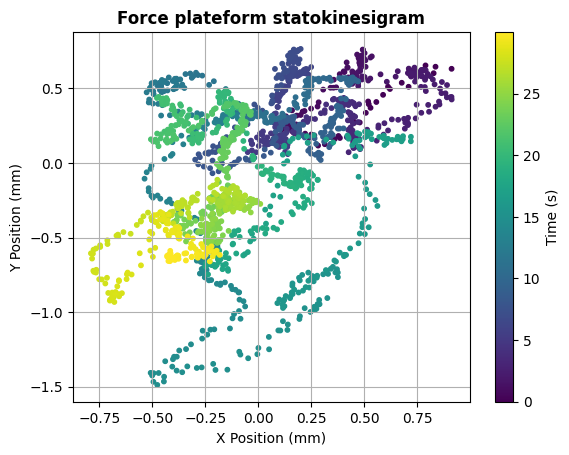

In [215]:
x = x_pos - np.mean(x_pos)
y = y_pos - np.mean(y_pos)

modulus = np.sqrt(x**2 + y**2)
angle = np.arctan2(y, x)

modulus95 = modulus[modulus <= np.percentile(modulus, 95)]
rmax = np.max(modulus95)

mod_norm = modulus / rmax
x_norm = mod_norm * np.cos(angle)
y_norm = mod_norm * np.sin(angle)

plt.figure()
sc = plt.scatter(x_norm, y_norm, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Force plateform statokinesigram", fontweight='bold')
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

## Getting CoP variables

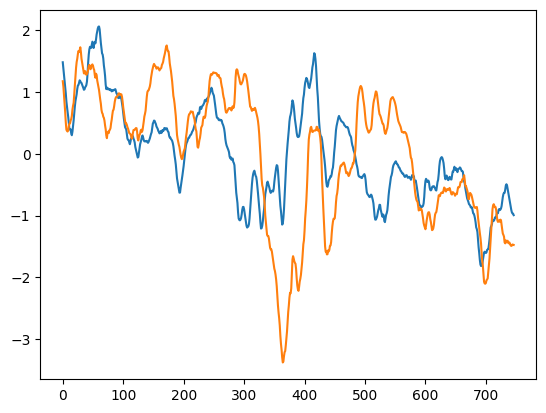

In [216]:
data = np.array([x_pos/10, y_pos/10]).T
stato = Stabilogram()
stato.from_array(array=data, original_frequency=60)

plt.plot(stato.medio_lateral)
plt.plot(stato.antero_posterior)

In [217]:
sway_density_radius = 0.3 # 3 mm
params_dic = {"sway_density_radius": sway_density_radius}
features = compute_all_features(stato, params_dic=params_dic)

In [218]:
features

{'mean_value_ML': np.float64(1.0243040983305541e-15),
 'mean_value_AP': np.float64(-4.0091387000352874e-17),
 'mean_distance_ML': np.float64(0.6589383543703707),
 'mean_distance_AP': np.float64(0.9303323020012866),
 'mean_distance_Radius': np.float64(1.208659531926494),
 'maximal_distance_ML': np.float64(2.0617092582390004),
 'maximal_distance_AP': np.float64(3.3758012229524583),
 'maximal_distance_Radius': np.float64(3.5593737425031216),
 'rms_ML': np.float64(0.7883030889960309),
 'rms_AP': np.float64(1.1017420533154172),
 'rms_Radius': np.float64(1.3547166907380876),
 'range_ML': np.float64(3.876605289217509),
 'range_AP': np.float64(5.130167835294467),
 'range_ML_AND_AP': np.float64(5.6510340076545535),
 'range_ratio_ML_AND_AP': np.float64(0.7556488235233333),
 'planar_deviation_ML_AND_AP': np.float64(1.3547166907380879),
 'coefficient_sway_direction_ML_AND_AP': np.float64(0.4466252021291454),
 'confidence_ellipse_area_ML_AND_AP': np.float64(14.724982703454609),
 'principal_sway_dir

In [219]:

def get_descriptors(x_pos, y_pos, time):
    data = np.array([x_pos/10, y_pos/10]).T

    stato = Stabilogram()
    stato.from_array(array=data, original_frequency=1/time[1])
    sway_density_radius = 0.3 # 3 mm
    params_dic = {"sway_density_radius": sway_density_radius}
    features = compute_all_features(stato, params_dic=params_dic)

    return features 

## Little comparison of radar based stabilogram and force platform one 


In [220]:
# df = pd.read_csv("../results/antoine/test1_position.csv")
# time_radar = df["time"].values
# x_pos_radar = df["x_pos"].values
# y_pos_radar = df["y_pos"].values

# plt.figure(figsize=(10, 6))
# plt.suptitle("Radar and Force plateform Stabilogram Centered", fontweight='bold')

# plt.subplot(2, 1, 1)
# plt.plot(time_radar, x_pos_radar, label="radar")
# plt.plot(times, x_pos, label="force platform")
# plt.xlabel("time (s)")
# plt.ylabel("ML (mm)")
# plt.title("ML axis")
# plt.legend()
# plt.grid

# plt.subplot(2, 1, 2)
# plt.plot(time_radar, y_pos_radar, label="radar")
# plt.plot(times, y_pos, label="force platform")
# plt.xlabel("time (s)")
# plt.ylabel("AP (mm)")
# plt.title("AP axis")
# plt.legend()
# plt.grid

# plt.tight_layout(pad=2)
# plt.show()

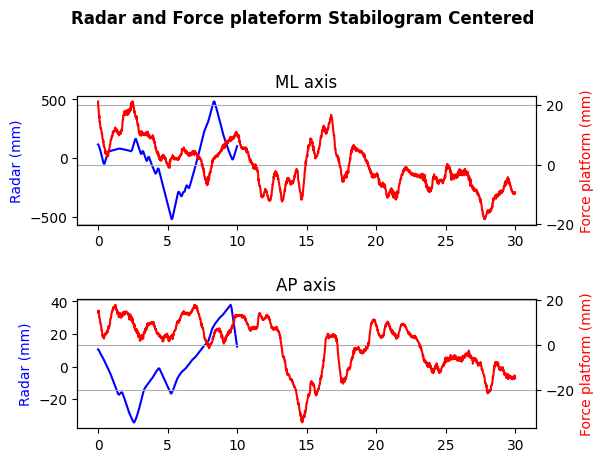

In [221]:
df = pd.read_csv("../results/tables/dataset1/position/data5_radarposition.csv")
time_radar = df["time"].values
x_pos_radar = df["x_pos"].values
y_pos_radar = df["y_pos"].values

plt.figure()
plt.suptitle("Radar and Force plateform Stabilogram Centered", fontweight='bold')

plt.subplot(2, 1, 1)

ax1 = plt.gca()  # axe gauche
ax1.plot(time_radar, x_pos_radar, label="radar", color='blue')
ax1.set_ylabel("Radar (mm)", color='blue')

ax2 = ax1.twinx()  # axe droit
ax2.plot(times, x_pos, label="force platform", color='red')
ax2.set_ylabel("Force platform (mm)", color='red')

plt.xlabel("time (s)")
plt.title("ML axis")
plt.grid()

plt.subplot(2, 1, 2)
ax1 = plt.gca()  # axe gauche
ax1.plot(time_radar, y_pos_radar, label="radar", color='blue')
ax1.set_ylabel("Radar (mm)", color='blue')

ax2 = ax1.twinx()  # axe droit
ax2.plot(times, y_pos, label="force platform", color='red')
ax2.set_ylabel("Force platform (mm)", color='red')

plt.xlabel("time (s)")
plt.title("AP axis")
plt.grid()

plt.tight_layout(pad=2)
plt.show()

In [222]:
def plot_stabilo_comparison(radar_stabilo_file, pf_time, pf_x, pf_y, save_path=None):

    df = pd.read_csv(radar_stabilo_file)
    time_radar = df["time"].values
    x_pos_radar = df["x_pos"].values
    y_pos_radar = df["y_pos"].values

    plt.figure(figsize=(10, 6))
    plt.suptitle("Radar and Force plateform Stabilogram Centered", fontweight='bold')

    ratio_x =  abs(np.log10(np.max(np.abs(x_pos_radar))) - np.log10(np.max(np.abs(pf_x)))) if (np.max(np.abs(x_pos_radar)) != 0 and np.max(np.abs(pf_x)) != 0) else 0
    ratio_y =  abs(np.log10(np.max(np.abs(y_pos_radar))) - np.log10(np.max(np.abs(pf_y)))) if (np.max(np.abs(y_pos_radar)) != 0 and np.max(np.abs(pf_y)) != 0) else 0

    print(ratio_x)
    print(ratio_y)


    # SI L'ORDRE DE GRANDEUR ENTRE RADAR ET PLATEFORME N'ETS PAS CORRECT
    if abs(ratio_x) > 0.5: 
    
        plt.subplot(2, 1, 1)

        ax1 = plt.gca()  # axe gauche
        ax1.plot(time_radar, x_pos_radar, label="radar", color='navy')
        ax1.set_ylabel("Radar (mm)", color='navy')

        ax2 = ax1.twinx()  # axe droit
        ax2.plot(pf_time, pf_x, label="force platform", color='orange')
        ax2.set_ylabel("Force platform (mm)", color='orange')

        plt.xlabel("time (s)")
        plt.title("ML axis")
        plt.grid()

    else : 
        plt.subplot(2, 1, 1)
        plt.plot(time_radar, x_pos_radar, label="radar")
        plt.plot(times, x_pos, label="force platform")
        plt.xlabel("time (s)")
        plt.ylabel("ML (mm)")
        plt.title("ML axis")
        plt.legend()
        plt.grid

    if abs(ratio_y) > 0.5:
        plt.subplot(2, 1, 2)
        ax1 = plt.gca()  # axe gauche
        ax1.plot(time_radar, y_pos_radar, label="radar", color='navy')
        ax1.set_ylabel("Radar (mm)", color='navy')

        ax2 = ax1.twinx()  # axe droit
        ax2.plot(pf_time, pf_y, label="force platform", color='orange')
        ax2.set_ylabel("Force platform (mm)", color='orange')

        plt.xlabel("time (s)")
        plt.title("AP axis")
        plt.grid()

    else : 
        plt.subplot(2, 1, 2)
        plt.plot(time_radar, y_pos_radar, label="radar")
        plt.plot(times, y_pos, label="force platform")
        plt.xlabel("time (s)")
        plt.ylabel("AP (mm)")
        plt.title("AP axis")
        plt.legend()
        plt.grid

        
    plt.tight_layout(pad=2)

    if save_path is not None:
        plt.savefig(save_path)
    plt.show()


## Dataset1 platform stabilogram and comparison

processing test file 1 !!!!
0.09494711657466937
0.007386139480825449


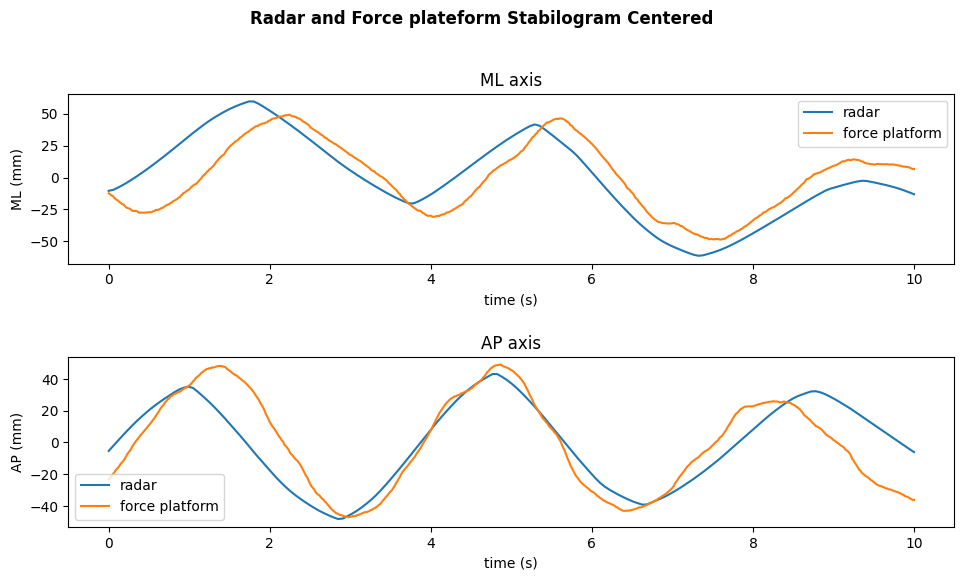

processing test file 2 !!!!
0.008563696049761704
0.01482744049797513


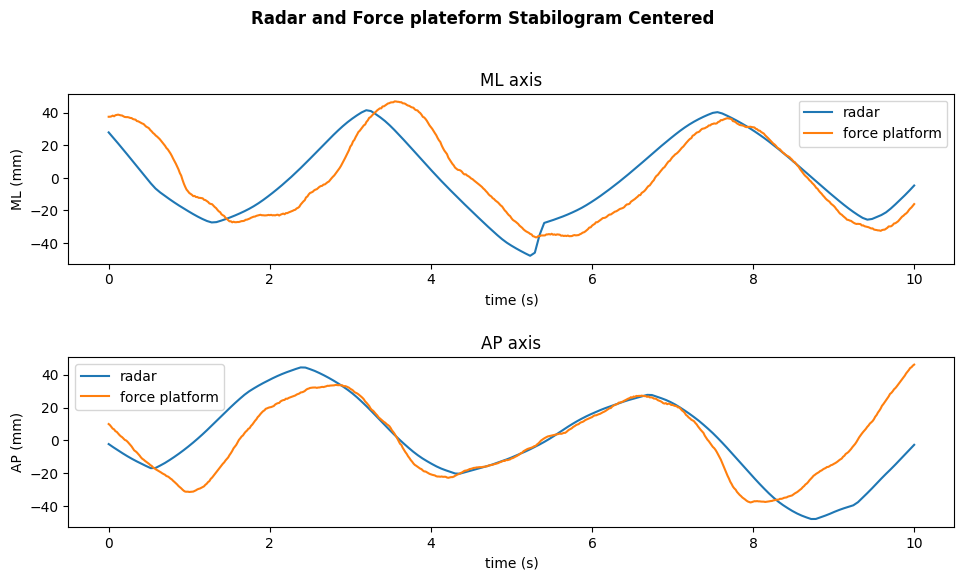

processing test file 3 !!!!
0.0009618165754146091
0.08442219620518188


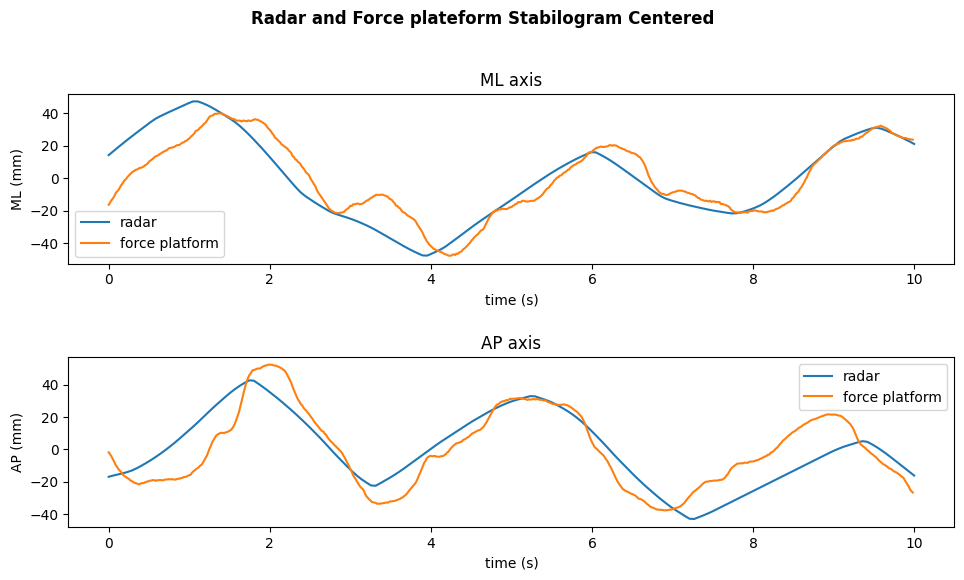

processing test file 4 !!!!
0.06668628733417403
0.012795262900470616


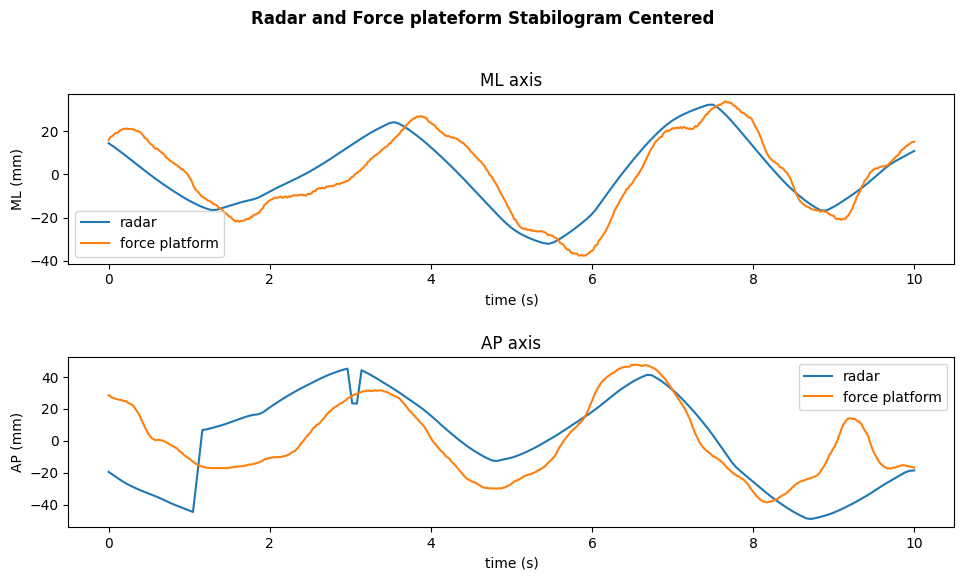

processing test file 5 !!!!
2.0321955906219786
0.6115076042164146


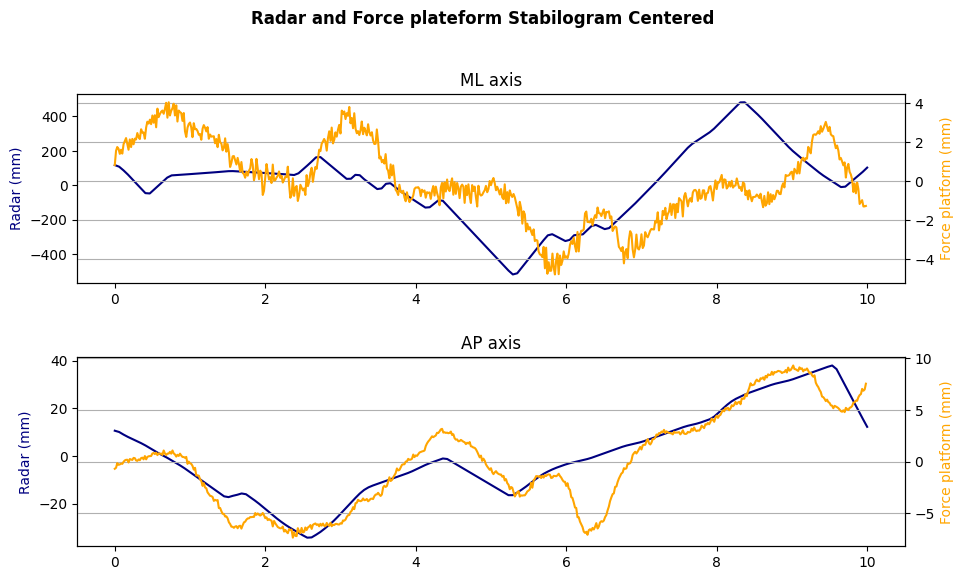

In [223]:
features_list = []

for i in range(1, 6):
    print(f"processing test file {i} !!!!")

    xml_file = f"../data/dataset1/platform/data{i}.xml"
    gait_file = f"../data/dataset1/platform/data{i}_gait.csv"
    radar_stabilo_file = f"../results/tables/dataset1/position/data{i}_radarposition.csv"

    begin_time = get_begin_time(xml_file)
    times, x_pos, y_pos = get_gait_samples(gait_file)

    times = times + begin_time
    positive_time = np.where((times >= 0) & (times <= 10))
    times = times[positive_time]
    x_pos = x_pos[positive_time]
    y_pos = y_pos[positive_time]

    x_pos -= np.mean(x_pos)
    y_pos -= np.mean(y_pos)

    plot_stabilo_comparison(radar_stabilo_file, times, x_pos, y_pos, f"../results/figures/dataset1/data{i}_stabilo.png")

    features = get_descriptors(x_pos, y_pos, times)
    features_list.append(features)

df_features = pd.DataFrame(features_list)
df_features.to_csv("../results/tables/dataset1/platform_descriptors.csv")

## Dataset2 platform stabilogram and comparison

processing test file 1 !!!!
1.2489583127771564
2.0981062619650768


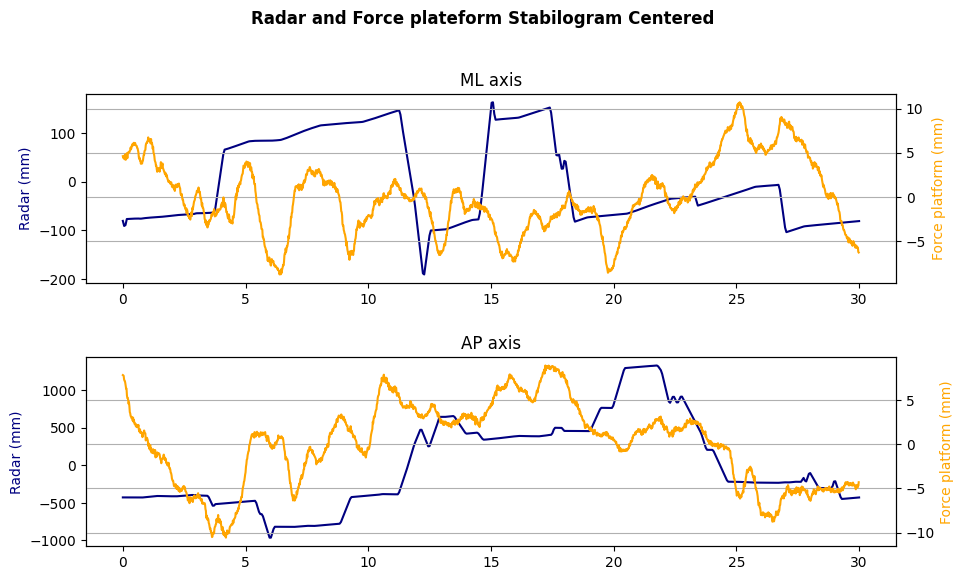

processing test file 2 !!!!
1.0382294102874075
1.5980806957541378


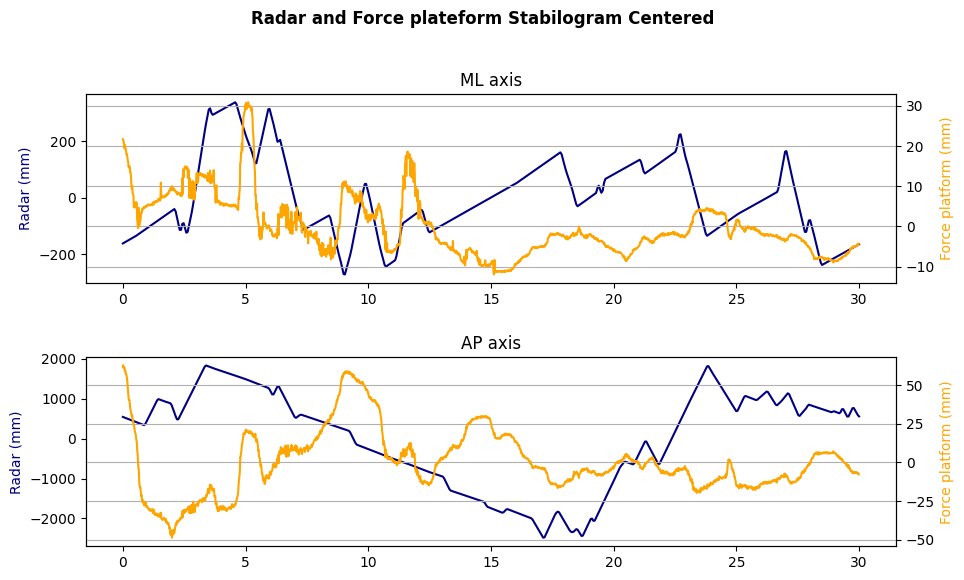

processing test file 3 !!!!
1.2559567305140344
0.6213435142318355


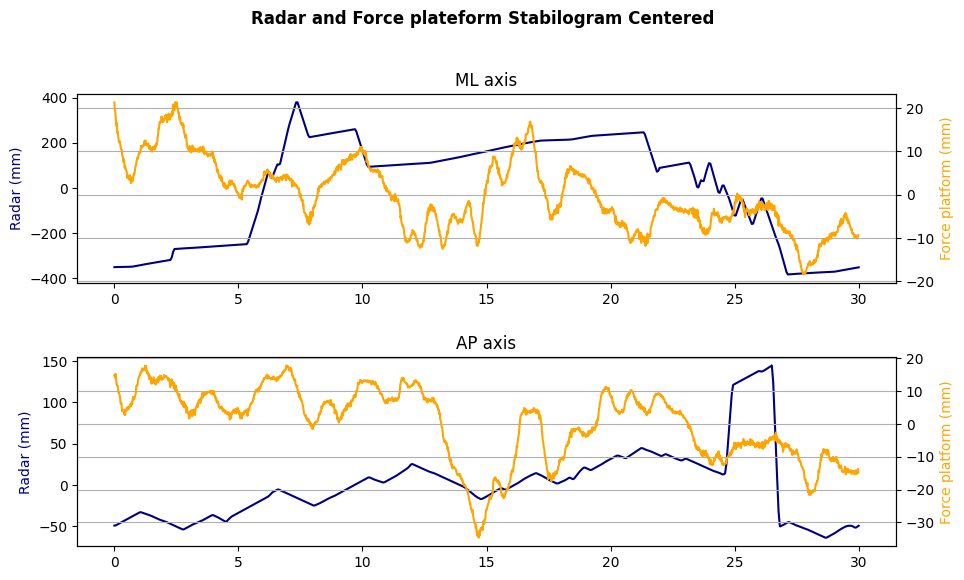

processing test file 4 !!!!
1.4456457847785713
1.4544619603901703


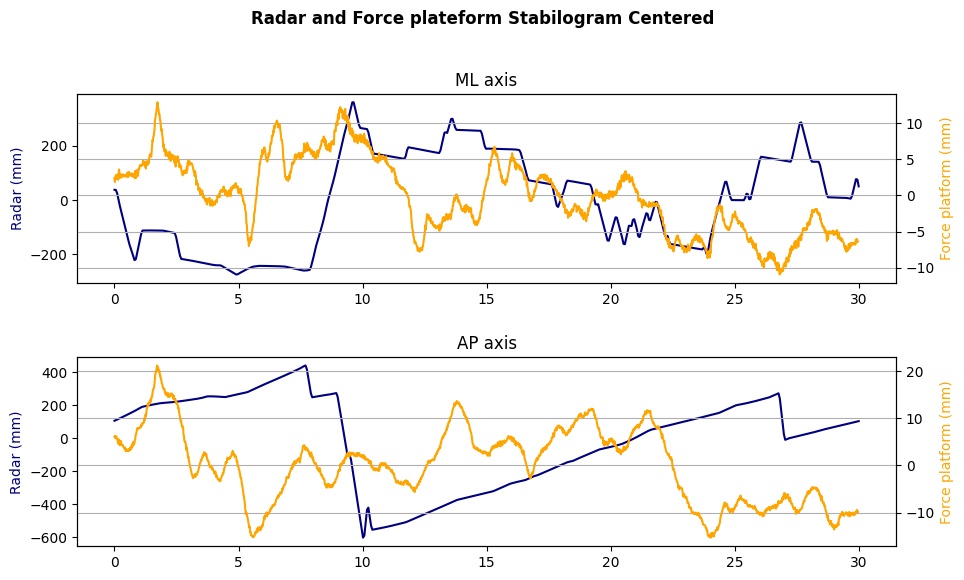

processing test file 5 !!!!
1.3050946428495214
1.942870521790803


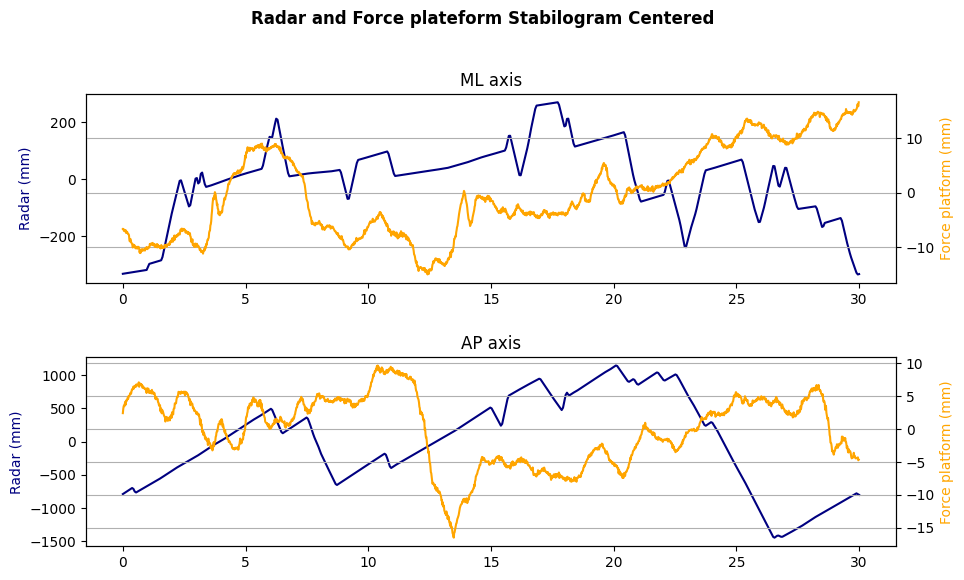

processing test file 6 !!!!
2.0164244442812294
2.273064087847937


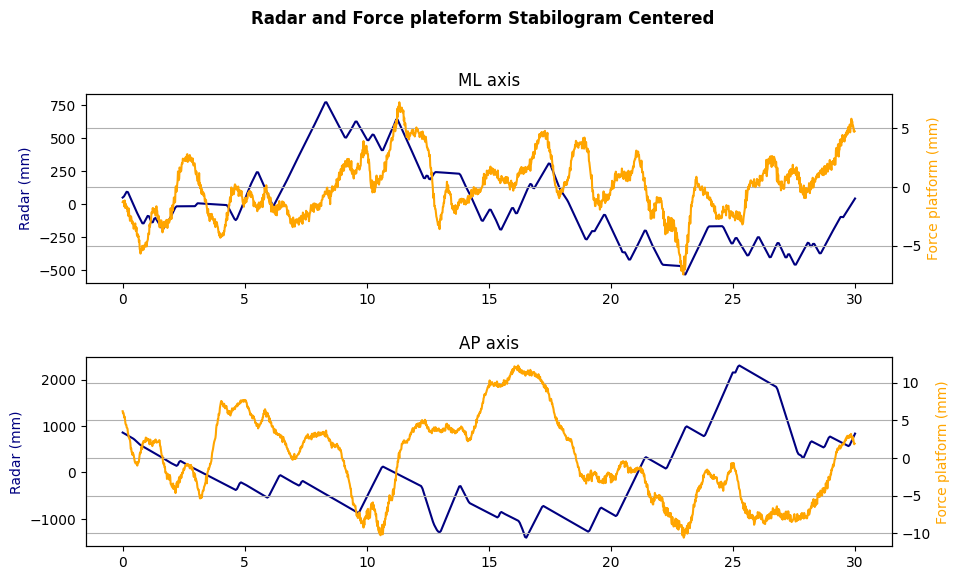

processing test file 7 !!!!
1.3420620444430884
2.423809474073189


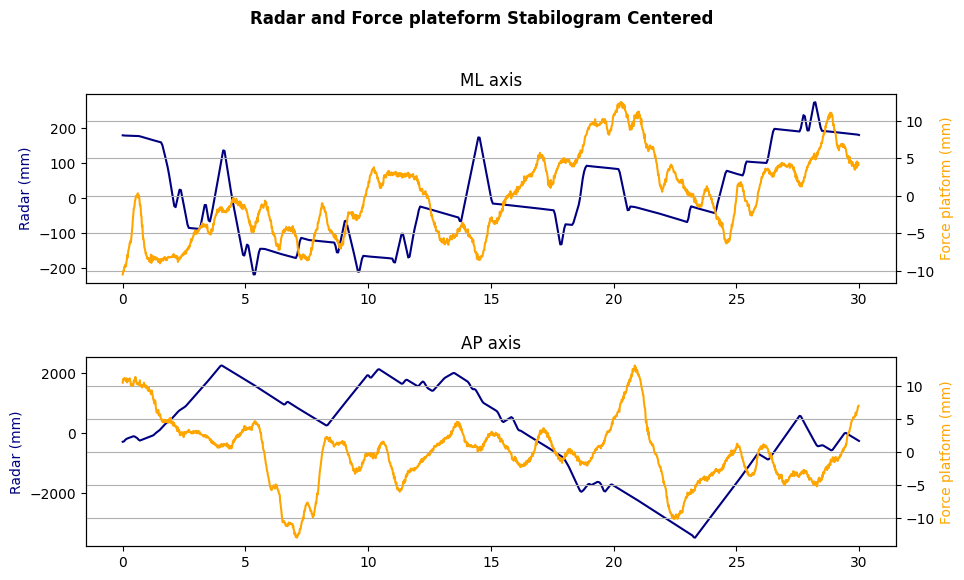

processing test file 8 !!!!
0.06473628311012147
0.11946913628010059


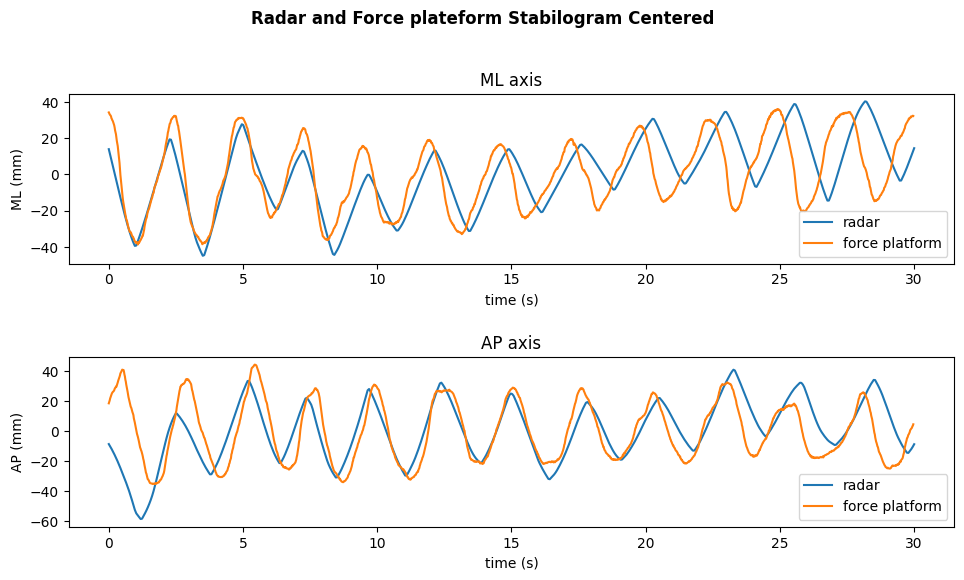

processing test file 9 !!!!
0.02884805222061848
0.004268219955195329


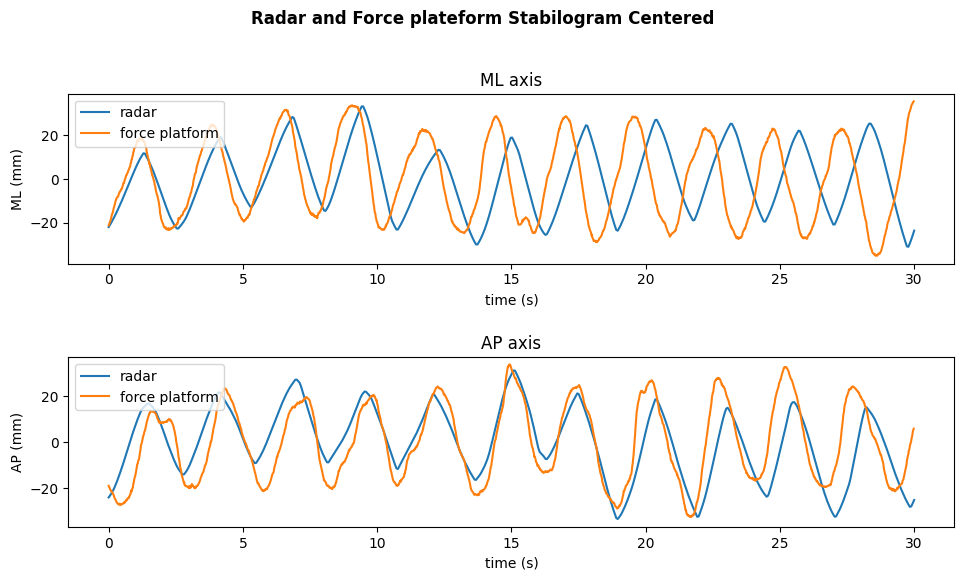

processing test file 10 !!!!
0.11052732225232664
0.04814741327572247


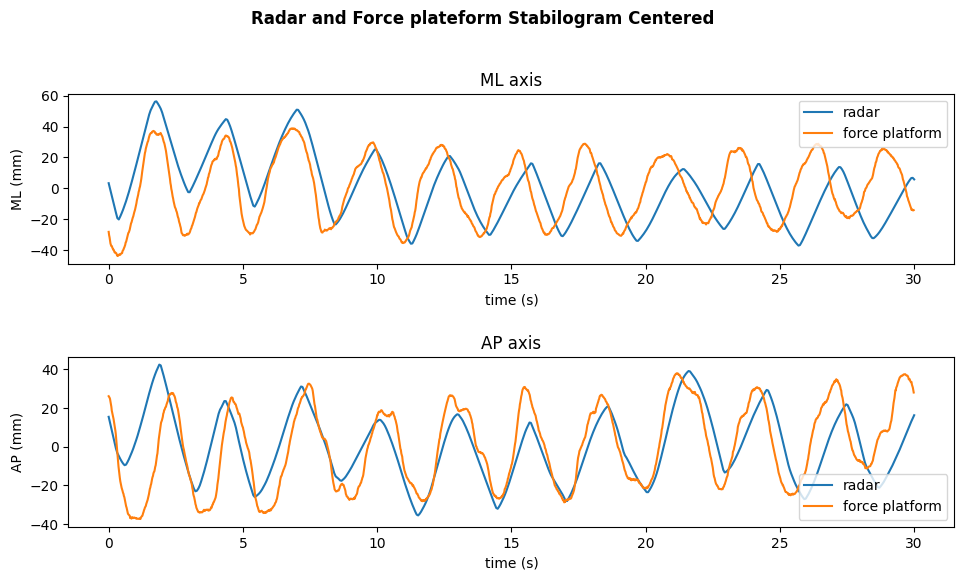

processing test file 11 !!!!
0.07422409979417699
0.0158261389808092


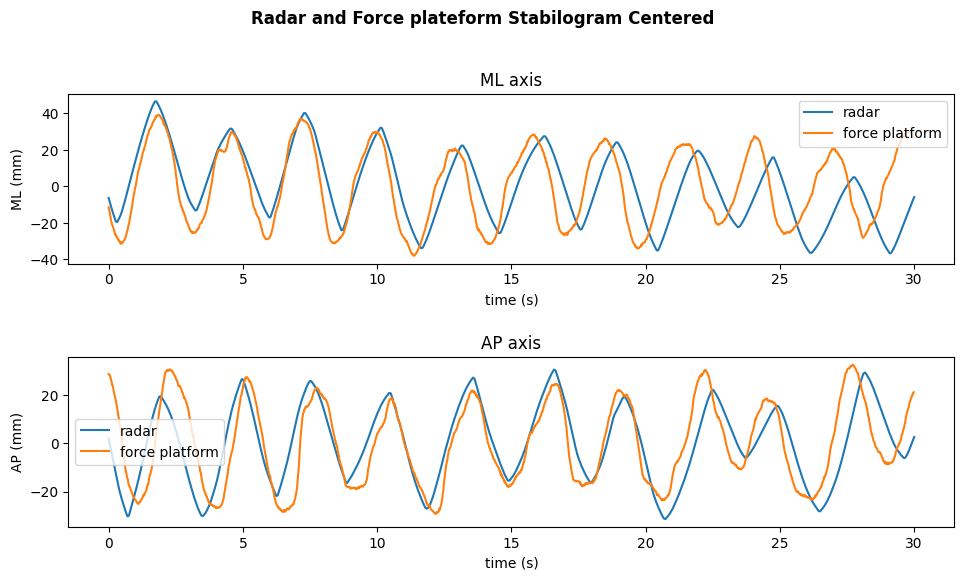

processing test file 12 !!!!
0.13219172762566633
0.08077376791201618


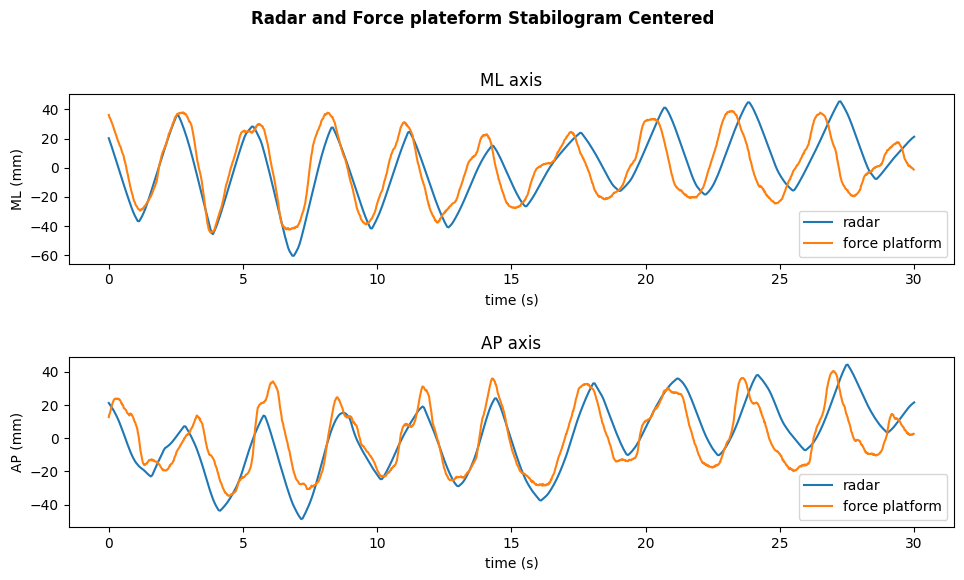

processing test file 13 !!!!
0.1365581150445363
0.05271552537105295


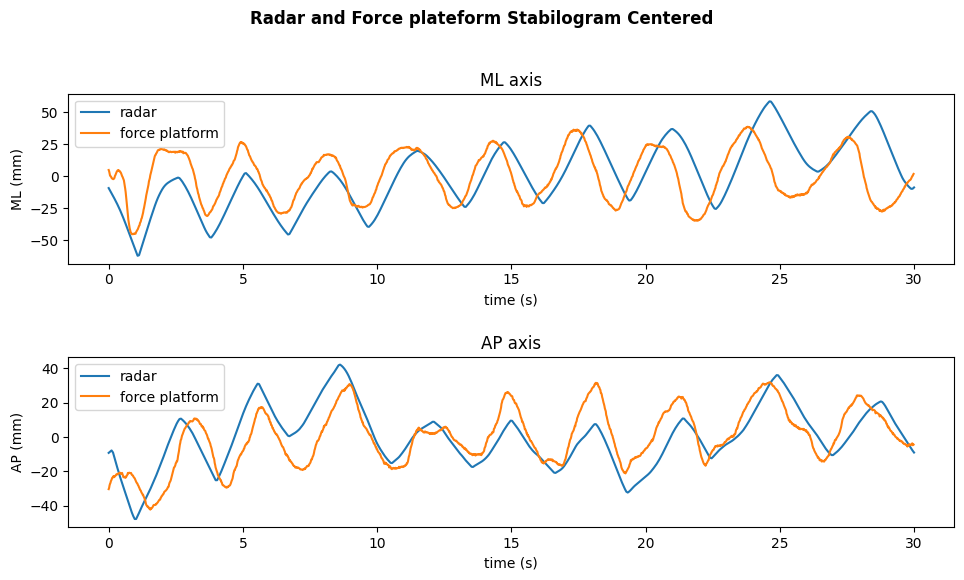

In [224]:
features_list = []

for i in range(1, 14):
    print(f"processing test file {i} !!!!")

    xml_file = f"../data/dataset2/platform/test{i}.xml"
    gait_file = f"../data/dataset2/platform/test{i}_gait.csv"
    radar_stabilo_file = f"../results/tables/dataset2/position/test{i}_radarposition.csv"

    begin_time = get_begin_time(xml_file)
    times, x_pos, y_pos = get_gait_samples(gait_file)

    times = times + begin_time
    positive_time = np.where(times >= 0)
    times = times[positive_time]
    x_pos = x_pos[positive_time]
    y_pos = y_pos[positive_time]

    x_pos -= np.mean(x_pos)
    y_pos -= np.mean(y_pos)

    plot_stabilo_comparison(radar_stabilo_file, times, x_pos, y_pos, f"../results/figures/dataset2/test{i}_stabilo.png")

    features = get_descriptors(x_pos, y_pos, times)
    features_list.append(features)

df_features = pd.DataFrame(features_list)
df_features.to_csv("../results/tables/dataset2/platform_descriptors.csv")